<a href="https://colab.research.google.com/github/yarabedair/deep-learning-/blob/main/Copy_of_CV_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Computer Vision Workshop: Natural Scene Classification

## 📌 Project Overview
In this workshop, you will build a complete computer vision pipeline to classify natural scene images into different categories such as buildings, forests, mountains, and more.

You will work with a real-world dataset and implement the full machine learning workflow — from data loading and preprocessing to model evaluation.

---

## 🎯 Objectives
By the end of this workshop, you will:
- Load and manage image datasets from directories
- Perform exploratory data analysis on image data
- Preprocess images for deep learning
- Build and train a Convolutional Neural Network (CNN)
- Evaluate model performance using multiple metrics

---

## 📊 Dataset Description
The dataset contains images of natural scenes categorized into 6 classes:
- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

Dataset structure:
- `seg_train/` → Training images
- `seg_test/` → Testing images
- `seg_pred/` → Optional prediction set

Total size:
- ~25,000 images
- Image size: ~150x150 pixels

---

## 🧪 Machine Learning Pipeline

### 1. Data Loading
- Load images from directory using `image_dataset_from_directory`

### 2. Data Exploration (EDA)
- Visualize sample images
- Check class balance
- Inspect image sizes

### 3. Data Preprocessing
- Resize images (e.g., 150x150)
- Normalize pixel values (0–255 → 0–1)
- Create training/validation splits

### 4. Model Building
- Build a CNN model with:
  - Convolutional layers
  - MaxPooling layers
  - Dense layers
- Use ReLU activation

### 5. Model Training
- Loss: Sparse Categorical Crossentropy
- Optimizer: Adam
- Metrics: Accuracy

### 6. Model Evaluation
Evaluate using:
- Accuracy
- Confusion Matrix
- Precision, Recall, F1-score

### 7. Model Improvement (Optional)
- Data augmentation (flip, rotation, zoom)
- Dropout layers
- Transfer learning (e.g., MobileNetV2)

---

## 🛠 Requirements

### Libraries
- TensorFlow / Keras
- NumPy
- Matplotlib
- Scikit-learn

### Tools
- Google Colab
- Kaggle account (for dataset download)

---

## ⚙️ Setup Instructions

1. Download dataset from Kaggle
2. Upload to Google Colab OR mount Google Drive
3. Extract dataset:
   ```bash
   !unzip archive.zip

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [2]:
!ls $path

seg_pred  seg_test  seg_train


In [3]:
import tensorflow as tf

# Define parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Path to dataset (update this based on your setup)
train_dir = f"/{path}/seg_train/seg_train"
test_dir = f"/{path}/seg_test/seg_test"

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

# Load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_dataset.class_names

print("Classes:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

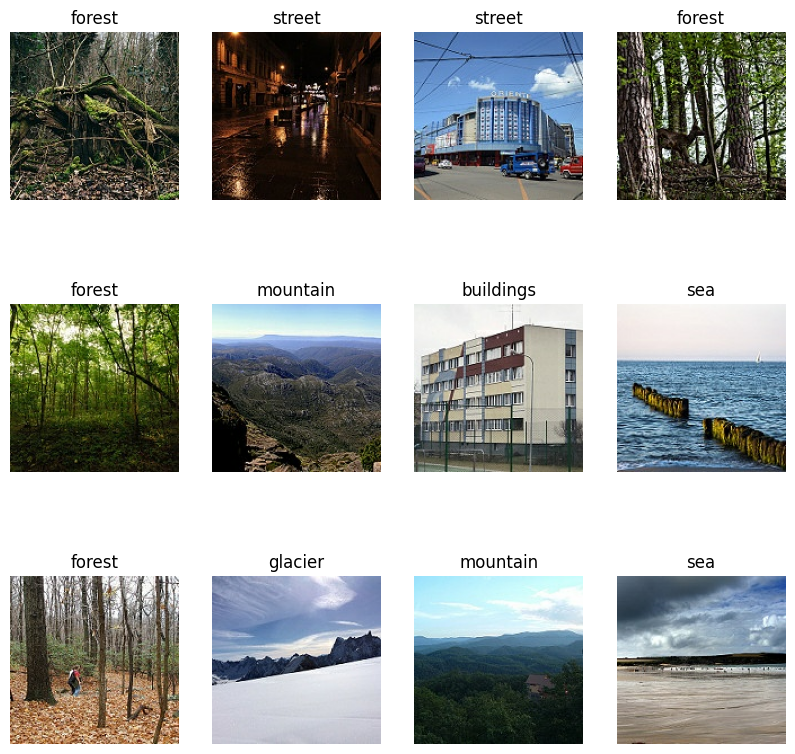

In [5]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [6]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [8]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - accuracy: 0.7845 - loss: 0.6093 - val_accuracy: 0.7733 - val_loss: 0.6237
Epoch 2/10
190/351 ━━━━━━━━━━━━━━━━━━━━ 4:19 2s/step - accuracy: 0.7876 - loss: 0.5910

In [11]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.7883 - loss: 0.6248
Test Accuracy: 0.7883333563804626


In [12]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 